# Nucleotide Transformer v2 finetuning

In [1]:
import os
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForMaskedLM, DataCollatorForLanguageModeling, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType
import gc
import matplotlib.pyplot as plt
import math

In [2]:
import torch
torch.__version__

'2.1.2+cu121'

## For bacteriophages

In [3]:
DATA_DIR="phage_data/"
DATASET_NAME="phage_clean_dataset"
MODEL_NAME="InstaDeepAI/nucleotide-transformer-v2-50m-multi-species"
OUTPUT_MODEL_NAME="model_weights/nt2-phages-lora-ncbi"
MAX_LEN = 2048

device="cuda"

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

### Get model with LoRA

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME, trust_remote_code=True)

In [5]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
model.to(device)

trainable params: 393,216 || all params: 56,298,188 || trainable%: 0.6984523196377119


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): EsmForMaskedLM(
      (esm): EsmModel(
        (embeddings): EsmEmbeddings(
          (word_embeddings): Embedding(4107, 512, padding_idx=1)
          (dropout): Dropout(p=0.0, inplace=False)
          (position_embeddings): Embedding(2050, 512, padding_idx=1)
        )
        (encoder): EsmEncoder(
          (layer): ModuleList(
            (0-11): 12 x EsmLayer(
              (attention): EsmAttention(
                (self): EsmSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=512, out_features=512, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=512, out_features=16, bias=False)
                    )
                    (lora_B): ModuleDict(
                      (default): Li

### Load dataset

In [6]:
dataset = Dataset.load_from_disk(os.path.join(DATA_DIR, DATASET_NAME))
# dataset = Dataset.from_dict({"sequence": dataset[:100000]["sequence"]})
dataset

Dataset({
    features: ['sequence'],
    num_rows: 208752
})

In [7]:
# Alternative tokenizer
def tokenize(batch):
    return tokenizer(
        batch["sequence"],
        truncation=True,
        max_length=MAX_LEN,
    )

tokenized = dataset.map(tokenize, batched=True, remove_columns=["sequence"], num_proc=16).train_test_split(test_size=0.1, seed=42)

### Train

In [8]:
collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

In [ ]:
batch_size = 64

training_args = TrainingArguments(
    output_dir=OUTPUT_MODEL_NAME,
    overwrite_output_dir=True,
    eval_strategy="epoch",
    logging_strategy="steps",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=4,
    learning_rate=5e-4,
    weight_decay=0.01,
    # fp16=True,
    bf16=True,
    save_steps=400,
    logging_steps=100,
    num_train_epochs=50,
    # eval_on_start=True,
)

In [11]:
def clean_gpu():
    torch.cuda.empty_cache()
    gc.collect()
clean_gpu()

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=collator,
    tokenizer=tokenizer,
)

In [13]:
results = trainer.evaluate()
print(f"Initial Perplexity: {math.exp(results['eval_loss']):.2f}")

/home/pere.carrillo/micromamba/envs/pbi-finetune/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Initial Perplexity: 1176.68


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss


In [ ]:
print(f"Final Perplexity: {math.exp(trainer.state.log_history[-2]['eval_loss']):.2f}")

Final Perplexity: 922.38


In [ ]:
loss =[[a['step'],a['eval_loss']] for a in trainer.state.log_history if 'eval_loss' in a.keys()]
eval_loss = [c[1] for c in loss]
steps = [c[0] for c in loss]

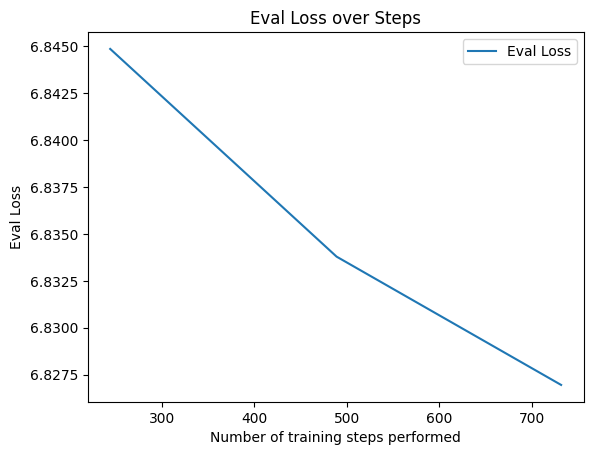

In [ ]:
plt.plot(steps, eval_loss, label='Eval Loss')
plt.title('Eval Loss over Steps')
plt.xlabel('Number of training steps performed')
plt.ylabel('Eval Loss')
plt.legend()
plt.show()

In [ ]:
trainer.save_model(OUTPUT_MODEL_NAME)

In [ ]:
clean_gpu()